In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from src.mlflow_setup import init_tracking
from src.data_split import wmae
import mlflow

init_tracking()

train = pd.read_csv('../data/train.csv')
train['Date'] = pd.to_datetime(train['Date'])

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 5.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 6.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 7.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 7.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.9 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 

ARIMA (AutoRegressive Integrated Moving Average) models a single time series using its own past values (AR), differencing to achieve stationarity (I), and past forecast errors (MA). SARIMA extends this with seasonal AR/I/MA terms to capture repeating patterns (e.g. yearly retail seasonality). Both work on one series at a time — they don't natively support the exogenous features (holidays, markdowns, CPI) or the many parallel Store/Dept series in this dataset, which is a key limitation versus tree-based or DL approaches. We test it on a representative Store/Dept series to compare against our other models.

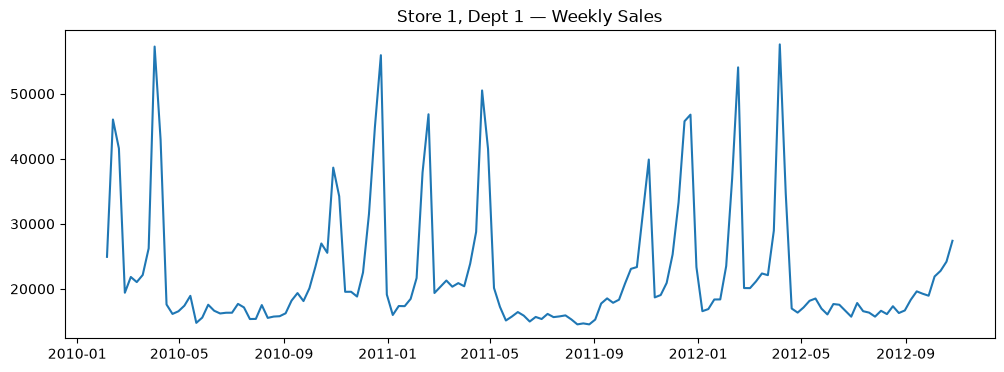

(143,)


In [3]:
sample = train[(train['Store'] == 1) & (train['Dept'] == 1)].sort_values('Date')
sample = sample.set_index('Date')['Weekly_Sales']

plt.figure(figsize=(12, 4))
plt.plot(sample.index, sample.values)
plt.title('Store 1, Dept 1 — Weekly Sales')
plt.show()

print(sample.shape)

In [4]:
val_weeks = 10
cutoff = sample.index.max() - pd.Timedelta(weeks=val_weeks)
train_series = sample[sample.index <= cutoff]
val_series = sample[sample.index > cutoff]

print(train_series.shape, val_series.shape)

(133,) (10,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_21748\3250850414.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff = sample.index.max() - pd.Timedelta(weeks=val_weeks)


In [5]:
from statsmodels.tsa.arima.model import ARIMA

mlflow.set_experiment("ARIMA_SARIMA_Training")

with mlflow.start_run(run_name="ARIMA_baseline"):
    order = (2, 1, 2)  # (p, d, q) — simple starting point
    mlflow.log_params({'p': order[0], 'd': order[1], 'q': order[2]})

    model = ARIMA(train_series, order=order)
    fitted = model.fit()

    forecast = fitted.forecast(steps=len(val_series))
    import numpy as np
    mae = np.mean(np.abs(val_series.values - forecast.values))

    mlflow.log_metric("val_mae", mae)
    print(f"ARIMA MAE: {mae:.2f}")

2026/07/12 20:18:28 INFO mlflow.tracking.fluent: Experiment with name 'ARIMA_SARIMA_Training' does not exist. Creating a new experiment.
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

ARIMA MAE: 3118.13
🏃 View run ARIMA_baseline at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/2/runs/bef78bb04b9e4a8eb73fce4d8f1a2978
🧪 View experiment at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/2


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

with mlflow.start_run(run_name="SARIMA_baseline"):
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, 52)
    mlflow.log_params({
        'p': order[0], 'd': order[1], 'q': order[2],
        'P': seasonal_order[0], 'D': seasonal_order[1], 'Q': seasonal_order[2], 's': seasonal_order[3]
    })

    model = SARIMAX(train_series, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=len(val_series))
    mae = np.mean(np.abs(val_series.values - forecast.values))

    mlflow.log_metric("val_mae", mae)
    print(f"SARIMA MAE: {mae:.2f}")

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA MAE: 1224.64
🏃 View run SARIMA_baseline at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/2/runs/7881ebebc1c741359331d0fc115fe241
🧪 View experiment at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/2


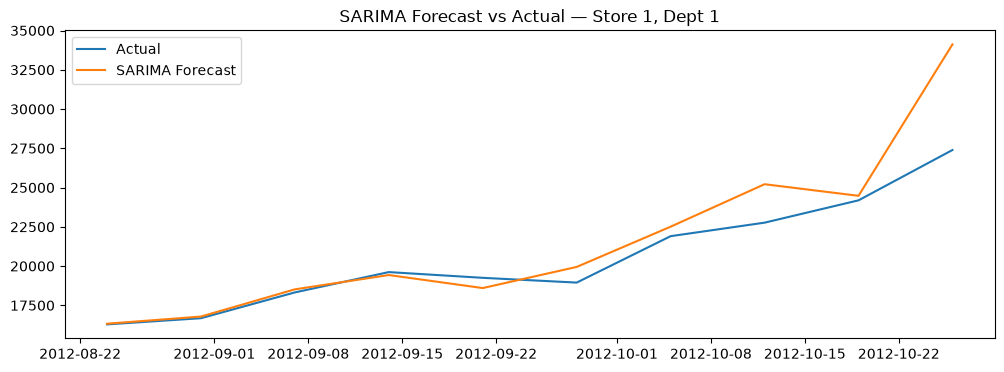

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(val_series.index, val_series.values, label='Actual')
plt.plot(val_series.index, forecast.values, label='SARIMA Forecast')
plt.legend()
plt.title('SARIMA Forecast vs Actual — Store 1, Dept 1')
plt.show()